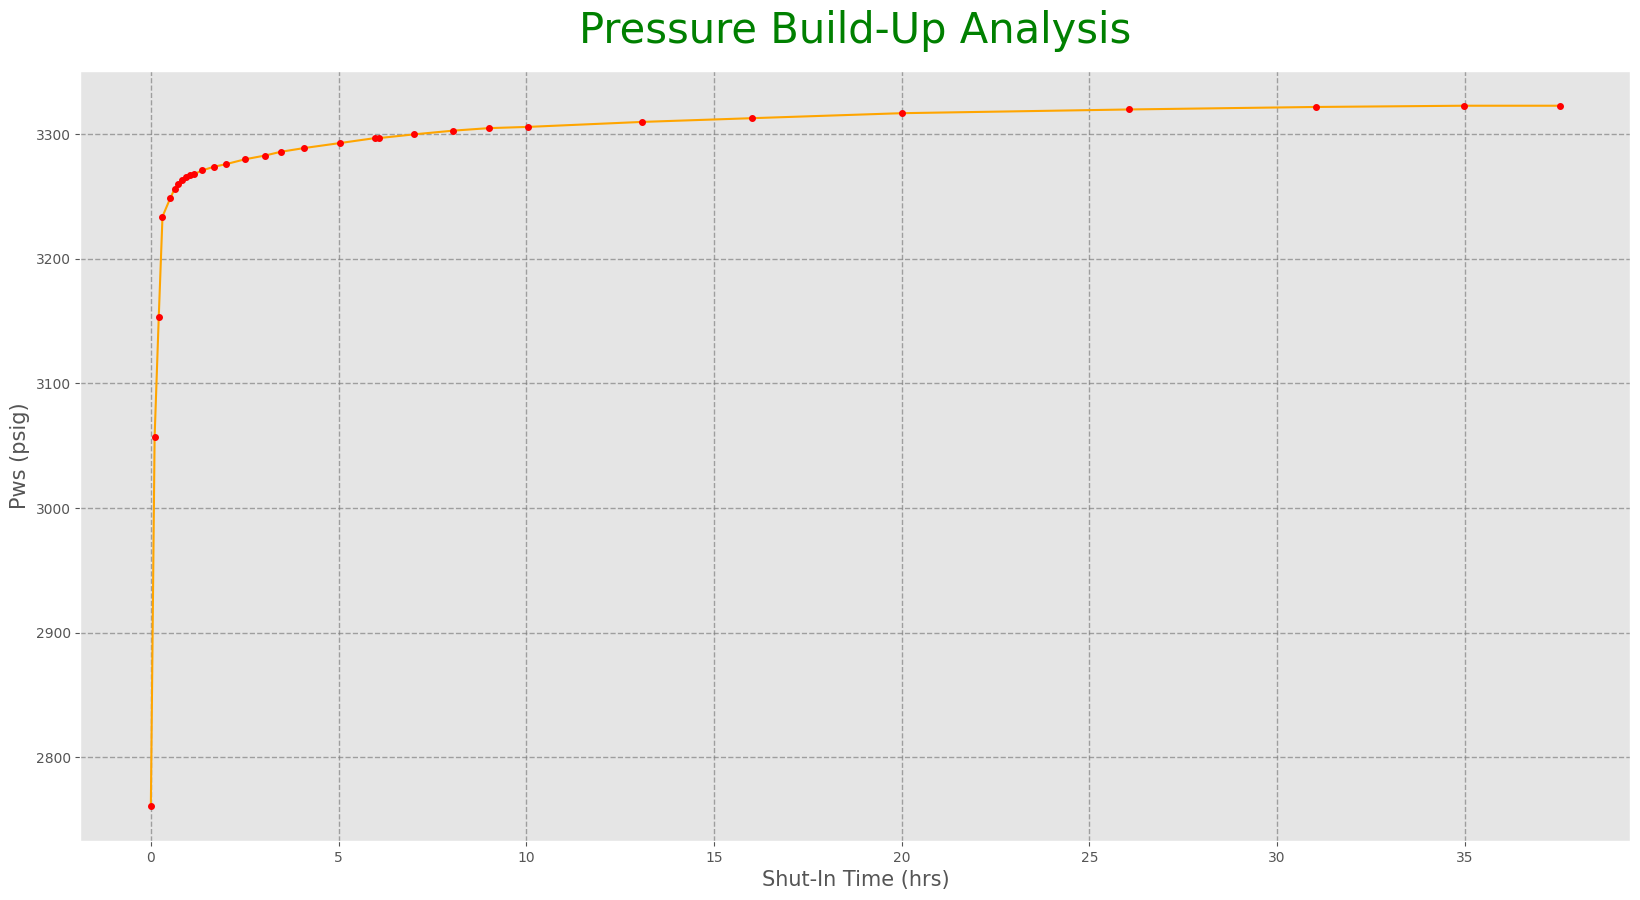

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Horners plot_data.xlsx')

# Well Parameters
depth = 10476
rw = 0.354
ct = 22.6*10**(-6)
Qo = 4900
tp = 310
H = 482
Pwf_initial = 2761
mu_o = 0.20
phi = 0.09
Bo = 1.55
casing_ID = 0.523

# Plot
plt.style.use('ggplot')

font_Title = {'color':'g','size':30}

plt.figure(figsize=(20,10))

plt.plot(df['del_T'], df['Pws'],
         marker='o', ms=4,
         mfc='r', mec='r',
         color='orange')

plt.grid(True, color='grey', lw=1, ls='--', alpha=0.7)

plt.xlabel('Shut-In Time (hrs)', fontsize= 15)
plt.ylabel('Pws (psig)', fontsize= 15)

plt.title("Pressure Build-Up Analysis", fontdict=font_Title, pad=20)

plt.show()

    del_T   Pws  tp + del_T  tp + del_T / del_T
0    0.00  2761      310.00                 inf
1    0.10  3057      310.10         3101.000000
2    0.21  3153      310.21         1477.190476
3    0.31  3234      310.31         1001.000000
4    0.52  3249      310.52          597.153846
5    0.63  3256      310.63          493.063492
6    0.73  3260      310.73          425.657534
7    0.84  3263      310.84          370.047619
8    0.94  3266      310.94          330.787234
9    1.05  3267      311.05          296.238095
10   1.15  3268      311.15          270.565217
11   1.36  3271      311.36          228.941176
12   1.68  3274      311.68          185.523810
13   1.99  3276      311.99          156.778894
14   2.51  3280      312.51          124.505976
15   3.04  3283      313.04          102.973684
16   3.46  3286      313.46           90.595376
17   4.08  3289      314.08           76.980392
18   5.03  3293      315.03           62.630219
19   5.97  3297      315.97           52

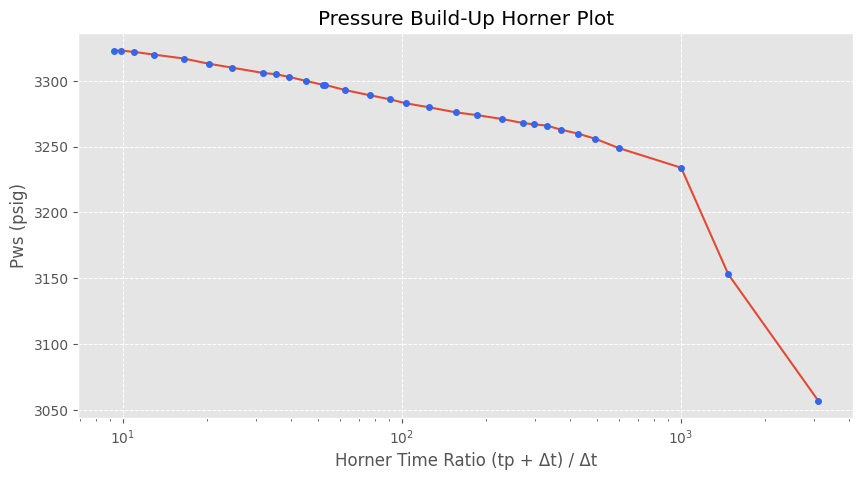

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# GIVEN WELL PARAMETER
# -------------------------
tp = 310   # production time (hours)

# -------------------------
# INPUT DATA
# -------------------------
data = {
"del_T":[0.00,0.10,0.21,0.31,0.52,0.63,0.73,0.84,0.94,1.05,
         1.15,1.36,1.68,1.99,2.51,3.04,3.46,4.08,5.03,5.97,
         6.07,7.01,8.06,9.00,10.05,13.09,16.02,20.00,26.07,
         31.03,34.98,37.54],

"Pws":[2761,3057,3153,3234,3249,3256,3260,3263,3266,3267,
       3268,3271,3274,3276,3280,3283,3286,3289,3293,3297,
       3297,3300,3303,3305,3306,3310,3313,3317,3320,3322,
       3323,3323]
}

# -------------------------
# CREATE DATAFRAME
# -------------------------
df = pd.DataFrame(data)

# -------------------------
# CALCULATIONS
# -------------------------
df['tp + del_T'] = tp + df['del_T']

df['tp + del_T / del_T'] = df['tp + del_T'] / df['del_T']

print(df)

# -------------------------
# HORNER SEMI-LOG PLOT
# -------------------------
plt.style.use('ggplot')

plt.figure(figsize=(10,5))

plt.semilogx(df['tp + del_T / del_T'], df['Pws'],
             marker='o',
             mec='#3467eb',
             mfc='#3467eb',
             ms=4)

plt.grid(True, ls='--', lw=0.7)

plt.xlabel('Horner Time Ratio (tp + Δt) / Δt')
plt.ylabel('Pws (psig)')

plt.title("Pressure Build-Up Horner Plot")

plt.show()

In [8]:
import numpy as np

# -----------------------------
# WELL PARAMETERS
# -----------------------------
Bo = 1.55
mu_o = 0.20
Qo = 4900
H = 482
phi = 0.09
ct = 22.6e-6
rw = 0.354
Pwf_initial = 2761

# -----------------------------
# SLOPE FROM HORNER PLOT
# -----------------------------
# Using straight-line points from semi-log plot
m = - (3310 - 3306) / (np.log10(24.682200) - np.log10(31.845771))

print("Slope (m) =", m)

# -----------------------------
# PERMEABILITY CALCULATION
# Formula:
# k = (162.6 * Bo * mu_o * Qo) / (m * H)
# -----------------------------
K = (162.6 * Bo * mu_o * Qo) / (m * H)

print(f"Average Permeability ≈ {K:.2f} milli-darcy")

# -----------------------------
# P1hr FROM HORNER PLOT
# -----------------------------
P1hr = 3266

# -----------------------------
# SKIN FACTOR CALCULATION
# -----------------------------
S = 1.151 * ((P1hr - Pwf_initial) / m - np.log10(K / (phi * mu_o * ct * rw**2)) + 3.23)

print(f"Skin Factor = {S:.2f}")

# -----------------------------
# INTERPRETATION
# -----------------------------
if S > 0:
    print("Positive skin factor → Formation damage near the wellbore")
elif S < 0:
    print("Negative skin factor → Well stimulation (fracture/acidizing)")
else:
    print("Skin factor ≈ 0 → No additional near-wellbore effects")

Slope (m) = 36.14417526475561
Average Permeability ≈ 14.18 milli-darcy
Skin Factor = 10.08
Positive skin factor → Formation damage near the wellbore
